# Analisis Genomik Virus Dengue (DENV) untuk Deteksi Dini Risiko Infeksi Sekunder Berdasarkan Identifikasi Serotipe Menggunakan Sequence Alignment dan Machine Learning
---

### Deskripsi Proyek
Proyek ini mengimplementasikan pendekatan hibrida untuk mengklasifikasikan empat serotipe Virus Dengue (DENV-1 hingga DENV-4) secara otomatis. Peningkatan fatalitas pada kasus Demam Berdarah Dengue (DBD) sering kali dipicu oleh **Infeksi Sekunder** heterolog akibat fenomena *Antibody-Dependent Enhancement* (ADE). 

Sistem ini memadukan:
1. **Dynamic Programming (Needleman-Wunsch):** Digunakan pada tahap *backend* (`main_feature_extraction.py`) untuk mentransformasikan sekuens nukleotida Gen *Envelope* (E) (~1485 bp) menjadi vektor fitur numerik 4-Dimensi berdasarkan skor keselarasan global (*global alignment*).
2. **Feedforward Neural Network (Multilayer Perceptron):** Dilatih di dalam notebook ini untuk mengidentifikasi serotipe patogen secara instan berdasarkan fitur jarak genomik tersebut.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

csv_path = '../data/genomic_features.csv'
df = pd.read_csv(csv_path)

## Tahap 1: EDA & Identitas Data

Sebelum melakukan pelatihan model, kita perlu memvalidasi apakah fitur numerik yang dihasilkan oleh algoritma *Sequence Alignment* memiliki pemisahan nilai yang cukup signifikan secara biologis antar-serotipe. Kita akan memeriksa cuplikan data, distribusi kelas, dan visualisasi *boxplot* dari skor Needleman-Wunsch.

Distribusi Sampel per Serotipe:
True_Label
DENV-1    15
DENV-2    15
DENV-3    15
DENV-4    15
Name: count, dtype: int64

Head Matriks Fitur (5 Baris Pertama):


,Sample_ID,Score_DENV-1,Score_DENV-2,Score_DENV-3,Score_DENV-4,True_Label
0,gi|1941608074|dbj|LC553235.1|,1385.0,467.0,608.0,450.0,DENV-1
1,gi|1941608070|dbj|LC553234.1|,1393.0,476.0,600.0,458.0,DENV-1
2,gi|2623916740|gb|OR844290.1|,1219.0,502.0,617.0,467.0,DENV-1
3,gi|2623916738|gb|OR844289.1|,1221.0,502.0,612.0,465.0,DENV-1
4,gi|2623916702|gb|OR844271.1|,1235.0,508.0,635.0,479.0,DENV-1


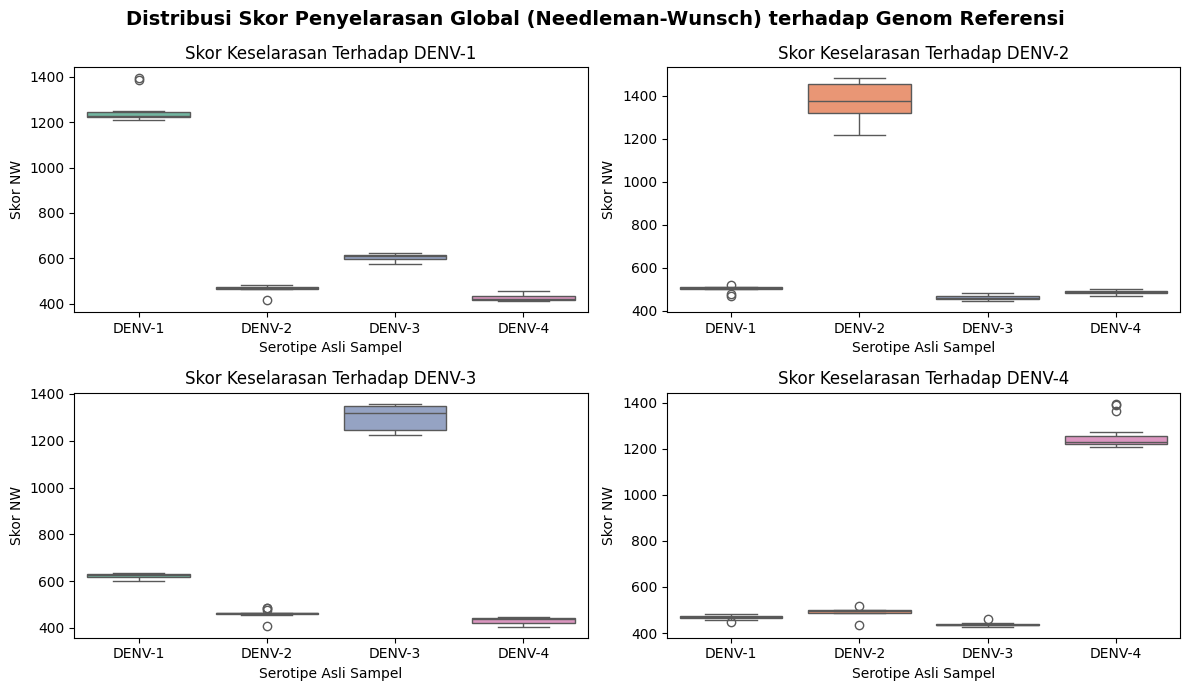

In [22]:
# Distribusi kelas sampel
print("Distribusi Sampel per Serotipe:")
print(df['True_Label'].value_counts())
print("\nHead Matriks Fitur (5 Baris Pertama):")
display(df.head())

# Boxplot Distribusi Skor Alignment
plt.figure(figsize=(12, 7))
plt.suptitle('Distribusi Skor Penyelarasan Global (Needleman-Wunsch) terhadap Genom Referensi', fontsize=14, weight='bold')

features = ['Score_DENV-1', 'Score_DENV-2', 'Score_DENV-3', 'Score_DENV-4']
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='True_Label', y=col, palette='Set2')
    plt.title(f'Skor Keselarasan Terhadap {col.split("_")[1]}')
    plt.xlabel('Serotipe Asli Sampel')
    plt.ylabel('Skor NW')

plt.tight_layout()
plt.show()

## Tahap 2: Pembagian Dataset & Konfigurasi Arsitektur Model FFNN

Pada tahap ini, data dipisahkan menjadi komponen Fitur ($X$) yang berisi 4 kolom skor keselarasan, dan Target ($y$) yang berisi label serotipe. Data kemudian dibagi dengan rasio **80:20** untuk *training* dan *testing*. 

Kita menerapkan teknik *stratified sampling* (`stratify=y`) untuk menjamin representasi kelas yang seimbang pada kedua subset data. Arsitektur model yang dipilih adalah **Feedforward Neural Network (FFNN)** dengan konfigurasi:
* **Hidden Layers:** 2 Lapisan penuh (`hidden_layer_sizes=(16, 8)`)
* **Fungsi Aktivasi:** Rectified Linear Unit (`relu`)
* **Optimizer:** Adam Solver dengan laju pembelajaran adaptif

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X = df[['Score_DENV-1', 'Score_DENV-2', 'Score_DENV-3', 'Score_DENV-4']]
y = df['True_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


ffnn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    verbose=True 
)

## Tahap 3: Proses Pelatihan Model & Analisis Kurva Loss

Kita akan melatih model FFNN agar mampu mengenali batas keputusan (*decision boundary*) dari fitur jarak genomik. Evaluasi proses pembelajaran dipantau secara langsung melalui kurva penurunan nilai *loss function* (Loss Curve) untuk memastikan model mengalami konvergensi dengan stabil tanpa indikasi *underfitting* atau *overfitting*.

Iteration 1, loss = 20.85359479
Iteration 2, loss = 17.74980784
Iteration 3, loss = 15.27503628
Iteration 4, loss = 12.69628881
Iteration 5, loss = 10.06579963
Iteration 6, loss = 7.43658267
Iteration 7, loss = 5.38714902
Iteration 8, loss = 4.33327260
Iteration 9, loss = 3.75741048
Iteration 10, loss = 3.35930843
Iteration 11, loss = 2.99505925
Iteration 12, loss = 2.63676822
Iteration 13, loss = 2.30309152
Iteration 14, loss = 2.07154890
Iteration 15, loss = 1.88897730
Iteration 16, loss = 1.72118100
Iteration 17, loss = 1.56513520
Iteration 18, loss = 1.41794979
Iteration 19, loss = 1.27906917
Iteration 20, loss = 1.14911789
Iteration 21, loss = 1.03233189
Iteration 22, loss = 0.92779117
Iteration 23, loss = 0.82950757
Iteration 24, loss = 0.73606358
Iteration 25, loss = 0.63489248
Iteration 26, loss = 0.58000059
Iteration 27, loss = 0.56842523
Iteration 28, loss = 0.59596774
Iteration 29, loss = 0.60659771
Iteration 30, loss = 0.60412495
Iteration 31, loss = 0.59642588
Iteration 32

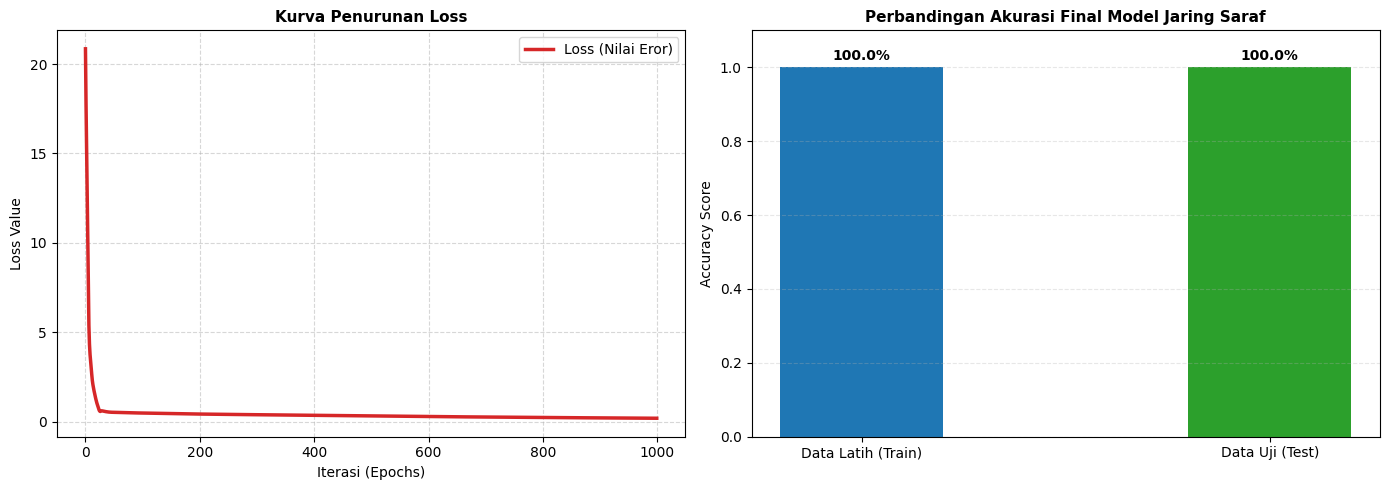

In [ ]:

ffnn_model.fit(X_train, y_train)
print(f"\nModel konvergen setelah {ffnn_model.n_iter_} iterasi.\n")
plt.figure(figsize=(14, 5))

# Kurva Loss Berdasarkan Iterasi Asli
plt.subplot(1, 2, 1)
plt.plot(ffnn_model.loss_curve_, color='#d62728', linewidth=2.5, label='Loss (Nilai Eror)')
plt.title('Kurva Penurunan Loss', fontsize=11, weight='bold')
plt.xlabel('Iterasi (Epochs)')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Akurasi Tahap Akhir 
train_acc = accuracy_score(y_train, ffnn_model.predict(X_train))
test_acc = accuracy_score(y_test, ffnn_model.predict(X_test))

plt.subplot(1, 2, 2)
plt.bar(['Data Latih (Train)', 'Data Uji (Test)'], [train_acc, test_acc], color=['#1f77b4', '#2ca02c'], width=0.4)
plt.ylim(0, 1.1)
plt.title('Perbandingan Akurasi Final Model', fontsize=11, weight='bold')
plt.ylabel('Accuracy Score')
for index, value in enumerate([train_acc, test_acc]):
    plt.text(index, value + 0.02, f"{value*100:.1f}%", ha='center', weight='bold')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Tahap 4: Evaluasi Performa Model Klasifikasi Serotipe

Tahap akhir ini mengevaluasi performa prediksi jaring saraf tiruan terhadap data uji (20% sisa sekuens misterius). Metrik pengujian dinilai menggunakan akurasi keseluruhan, *Precision*, *Recall*, dan *F1-Score*. Validasi visual disajikan dalam bentuk **Confusion Matrix** untuk mendeteksi apabila terjadi kesalahan klasifikasi atau salah diagnosis antar-serotipe yang berdekatan.

AKURASI AKHIR MODEL PADA DATA UJI: 100.00%

Laporan Performa Klasifikasi Genomik:
              precision    recall  f1-score   support

      DENV-1       1.00      1.00      1.00         3
      DENV-2       1.00      1.00      1.00         3
      DENV-3       1.00      1.00      1.00         3
      DENV-4       1.00      1.00      1.00         3

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



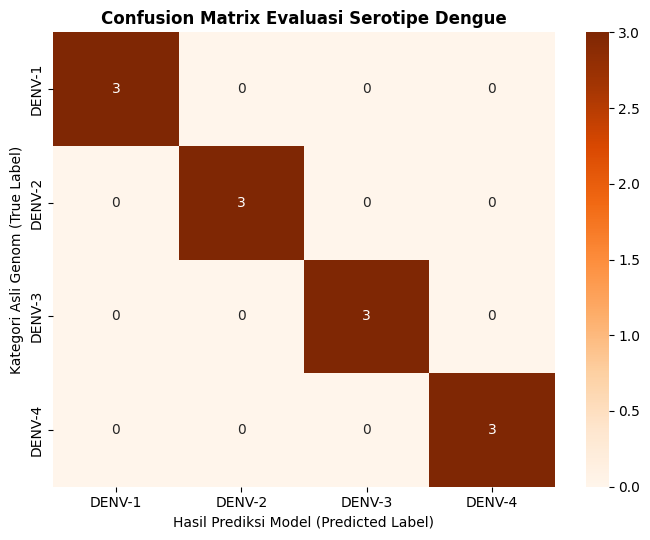

[INFO] Model cerdas biner .pkl berhasil diekspor ke folder /output.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Melakukan inferensi pada data uji
y_pred = ffnn_model.predict(X_test)

# Menghitung akurasi final
akurasi_final = accuracy_score(y_test, y_pred)
print(f"AKURASI AKHIR MODEL PADA DATA UJI: {akurasi_final * 100:.2f}%\n")

# Menampilkan Classification Report komprehensif
print("Laporan Performa Klasifikasi Genomik:")
print(classification_report(y_test, y_pred))

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['DENV-1', 'DENV-2', 'DENV-3', 'DENV-4'])

plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['DENV-1', 'DENV-2', 'DENV-3', 'DENV-4'],
            yticklabels=['DENV-1', 'DENV-2', 'DENV-3', 'DENV-4'])
plt.title('Confusion Matrix Evaluasi Serotipe Dengue', fontsize=12, weight='bold')
plt.ylabel('Kategori Asli Genom (True Label)')
plt.xlabel('Hasil Prediksi Model (Predicted Label)')
plt.tight_layout()
plt.show()

joblib.dump(ffnn_model, "../output/dengue_ffnn_model.pkl")
print("[INFO] Model cerdas biner .pkl berhasil diekspor ke folder /output.")